### Basic OpenSeesPy Commands
[Documentation](https://openseespydoc.readthedocs.io/en/latest/src/modelcmds.html)

In [1]:
import openseespy.opensees as ops
import matplotlib.pyplot as plt

#### Define Model Geometry
##### Lets look at a simple uniaxial truss problem

In [2]:
# before starting a new model, wipe history
ops.wipe()

# Define the modeling domain
# ---------------------------
    # ndm = number of spatial dimensions: we will mostly be working in 2D space
    # ndf = number of degrees of freedom: we will mostly be using 2 dofs at each node
    #       (for certain examples we may need to use 3 dofs, or multiple domains)
ops.model('basic','-ndm',2,'-ndf',2)


# Define nodes: ops.node(nodeTag, *coordinatePos_xy)
# ---------------------------
barLength = 5.0
ops.node(1,*[0.0,0.0])
ops.node(2,*[0.0,barLength])


# Define boundary condition: ops.fix(nodeTag, *fixityVals)
# ---------------------------
    # fixity defined for a single node at a time
    # 0 -> dof unrestrained; 1 -> dof restrained
ops.fix(1,*[1,1])    # restrain node 1 in x and y directions
ops.fix(2,*[1,0])    # need to restrain in x direction since our truss material provides no stiffness in this dof

# NOTE: the fix() command is a type of simple constraint, along with others. 
# One we may also use is equalDOF(), which constrains two nodes to share a displacement component


# Define material behavior. Let's define a simple elastic-plastic law for steel. Could describe reinforcement
# ---------------------------
barMaterial = 1
Es = 29000  # ksi
fsy = 60    # ksi
eps_y = fsy / Es
ops.uniaxialMaterial('ElasticPP',barMaterial,Es,eps_y)


# Define elements between nodes. All nodes must have some stiffness attached
# ---------------------------
    # Check documentation for all possible elements. There are too many
    # We will eventually use:
        # zeroLengthND (multiaxial element) Element to represent springs crossing a crack face
        # Truss Element (unixial element) to represent reinforcement
        # dispBeamColumn Element (fiber section element) to represent realistic reinforcement
        # Quad Element or Tri31 Element to represent concrete continuum
    # here, define a uniaxial truss element
trussArea = 1
barEleTag = 1
trussNodes = [1,2]
ops.element('Truss',barEleTag,*trussNodes,trussArea,barMaterial)

#### Apply Loads to the Model

In [3]:
# Define a timeSeries
# ---------------------------
# first need to define a timeSeries. This describes how the load factor changes in time. Options include:
    # Constant: could be useful for gravity loads
    # Linear: Useful for pushover analyses
    # Triangular: Oscillating loads
    # Path: Earthquake loads
# a model may have multiple timeSeries, e.g., constant TS for gravity load + path TS for EQ load
linTsTag = 1
ops.timeSeries('Linear',linTsTag)

# Define a load Pattern
# ---------------------------
# a loadPattern has a timeSeries associated with it. Options include:
    # Plain Pattern: can include nodal loads or nodal displacements
    # UniformExcitation: includes EQ accelerations
plainPatternTag = 1
ops.pattern('Plain',plainPatternTag,linTsTag)

# Define loads
# ---------------------------
# loads are enclosed within the most recent load pattern
# values of load 'felt' by model are the refLoadVector times the load factor in the timeSeries
loadedNode = 2               # node at which to apply load
barYieldForce = fsy * trussArea
refLoadVector = [0.0,barYieldForce]    # reference load vector
ops.load(loadedNode,*refLoadVector)

#### Analysis Options

In [4]:
# constraints handler: how are constraints (i.e. boundary conditions) enforced in sys of Equations?
    # Plain. Very common, but limited to simple constraints
    # Lagrange. 
    # Penalty. 
    # Transformation. We will use this often. But need to be careful
ops.constraints('Plain')

# node re-numberer scheme: manually defined nodal connectivity may give rise to large-bandwidth matrices. Renumberer re-bands it
ops.numberer('Plain')

# system of equations: can use space-spacing techniques to reduce memory required
ops.system('FullGeneral')

# solution algorithm: what approach to solve nonlinear equations?
ops.algorithm('Newton')

# equilibrium test: when is equilibrium satisfied? small displacement out-of-balance? Small force out-of-balance? Energy?
tol = 1e-5
numIter = 100
ops.test('NormDispIncr',tol,numIter)

# integrator: load-control or displacement control? We will likely use both for different examples
loadFacIncr = 0.01
ops.integrator('LoadControl',loadFacIncr)

# analysis type:
ops.analysis('Static')

#### Perform the Analysis

In [5]:
# set up some storage containers
P = []        # applied load
disp = []     # displacement at node 2
freeDOF = 2

# For our simple example, the load factor will be 1.0 when the actual load hits the target yield stress of the bar
numSteps = int(1/loadFacIncr)
for n in range(numSteps):
    # analyze 1 load increment at a time
    # result of analyze is 0 if OK; !=0 if equilibrium not found
    Failed = ops.analyze(1)             
    if not Failed:
        # we can query the nodes and elements with one of many Output commands
        eleForce = ops.eleForce(barEleTag,freeDOF)     # get element resisting force in dof 2  
        P.append(-eleForce)
        freeNodeDisp = ops.nodeDisp(loadedNode,freeDOF)             # get displacement of free node (w/ tag 2) in dof 2
        disp.append(freeNodeDisp)
    else:
        print('OpenSees analysis FAILED at load factor {:1.1f}'.format(n))
        break 

WARNING FullGenLinLapackSolver::solve() -factorization failed, matrix singular U(i,i) = 0, i= 0


#### Plot Output

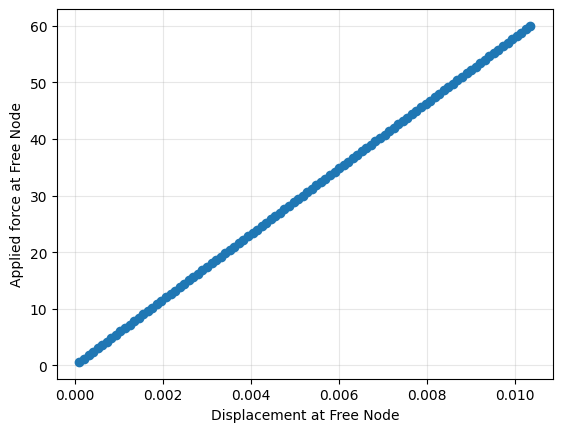

In [6]:
plt.plot(disp,P,'-o')
plt.xlabel('Displacement at Free Node')
plt.ylabel('Applied force at Free Node')
plt.grid(True,alpha=0.3)
plt.show()

#### Load Control Fails at Limit Point for this Example
##### Lets Try Displacement Control

In [7]:
def modelBuilder():
    """
    same model as before, but using DisplacementControl instead of LoadControl
    """
    
    ops.wipe()
    ops.model('basic','-ndm',2,'-ndf',2)
    
    ops.node(1,*[0.0,0.0])
    ops.node(2,*[0.0,5.0])
    ops.fix(1,*[1,1])    
    ops.fix(2,*[1,0])   
    freeDOF = 2

    barMaterial = 1
    Es = 29000  # ksi
    fsy = 60    # ksi
    eps_y = fsy / Es
    ops.uniaxialMaterial('ElasticPP',barMaterial,Es,eps_y)

    trussArea = 1
    barEleTag = 1
    trussNodes = [1,2]
    ops.element('Truss',barEleTag,*trussNodes,trussArea,barMaterial)

    linTsTag = 1
    ops.timeSeries('Linear',linTsTag)

    plainPatternTag = 1
    ops.pattern('Plain',plainPatternTag,linTsTag)

    loadedNode = 2
    barYieldForce = fsy * trussArea
    refLoadVector = [0.0,barYieldForce]
    ops.load(loadedNode,*refLoadVector)

    ops.constraints('Plain')
    ops.numberer('Plain')
    ops.system('FullGeneral')
    ops.algorithm('Newton')
    tol = 1e-5
    numIter = 100
    ops.test('NormDispIncr',tol,numIter)
    dispIncr = 0.001
    ops.integrator('DisplacementControl',loadedNode,freeDOF,dispIncr)
    ops.analysis('Static')

    return dispIncr

#### Do Incremental Analysis by Controlling Displacement Step

In [8]:
dispIncr = modelBuilder()

P = []
disp = []

# now perform analysis
targetDisp = 2*eps_y*barLength
numDispSteps = int(targetDisp / dispIncr)
for n in range(numDispSteps):
    Failed = ops.analyze(1)             
    if not Failed:
        eleForce = ops.eleForce(barEleTag,freeDOF) 
        P.append(-eleForce)
        freeNodeDisp = ops.nodeDisp(loadedNode,freeDOF)
        disp.append(freeNodeDisp)
    else:
        print('OpenSees analysis FAILED at load factor {:1.1f}'.format(n))
        break 

# NOTE: you'll get warnings that the matrix is singular, because once the bar is yielded there is no stiffness
#            ...according to our simplified material model in this problem. 
#            ...but see below that we still find the elastic-plastic response we expect, even past the yielding point

WARNING FullGenLinLapackSolver::solve() -factorization failed, matrix singular U(i,i) = 0, i= 0
WARNING FullGenLinLapackSolver::solve() -factorization failed, matrix singular U(i,i) = 0, i= 0
WARNING FullGenLinLapackSolver::solve() -factorization failed, matrix singular U(i,i) = 0, i= 0
WARNING FullGenLinLapackSolver::solve() -factorization failed, matrix singular U(i,i) = 0, i= 0
WARNING FullGenLinLapackSolver::solve() -factorization failed, matrix singular U(i,i) = 0, i= 0
WARNING FullGenLinLapackSolver::solve() -factorization failed, matrix singular U(i,i) = 0, i= 0
WARNING FullGenLinLapackSolver::solve() -factorization failed, matrix singular U(i,i) = 0, i= 0
WARNING FullGenLinLapackSolver::solve() -factorization failed, matrix singular U(i,i) = 0, i= 0
WARNING FullGenLinLapackSolver::solve() -factorization failed, matrix singular U(i,i) = 0, i= 0
WARNING FullGenLinLapackSolver::solve() -factorization failed, matrix singular U(i,i) = 0, i= 0
WARNING FullGenLinLapackSolver::solve() 

#### Plot Disp Control Output

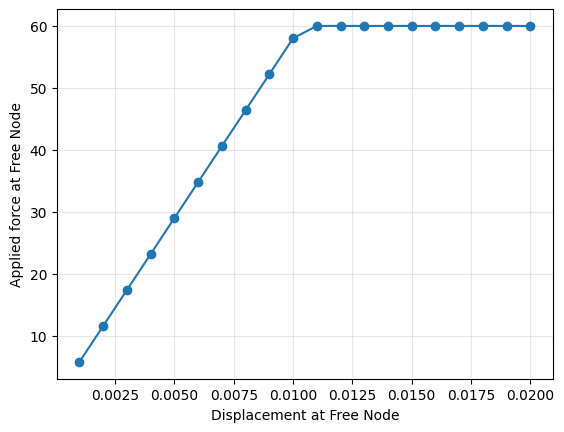

In [9]:
plt.plot(disp,P,'-o')
plt.xlabel('Displacement at Free Node')
plt.ylabel('Applied force at Free Node')
plt.grid(True,alpha=0.3)
plt.show()